# Week 8: Classificatiemodellen in Machine Learning

## Bibliotheken importeren

In [72]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import tree
from sklearn import metrics
import matplotlib.pyplot as plt

## Data inlezen en kolommen selecteren

In [73]:
df = pd.read_csv("vgsales.csv", sep=',')
df

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [74]:
df = df.loc[:, ['Rank', 'Year', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Platform', 'Publisher']]

# Code voor het numeriek weergeven van de echte getallen
sales_columns = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
for column in sales_columns:
    if column in df.columns: 
        df[column] = (df[column] * 1_000_000).astype(int)  


# DataFrame voor minder kolommen om overfitting te voorkomen
# df = df.loc[:, ['Rank', 'Year', 'NA_Sales', 'JP_Sales', 'Platform', 'Platform']]
# df

# df = df.loc[:, ['Rank', 'Year', 'Platform', 'Platform']]
# df

unieke_platforms = df['Platform'].unique()
print("De verschillende platforms zijn:", unieke_platforms)

platform_counts = df['Platform'].value_counts()
populaire_platforms = platform_counts[platform_counts > 1000].index
df = df[df['Platform'].isin(populaire_platforms)]

print("\nAantal games per platform:")
print(platform_counts)

df

De verschillende platforms zijn: ['Wii' 'NES' 'GB' 'DS' 'X360' 'PS3' 'PS2' 'SNES' 'GBA' '3DS' 'PS4' 'N64'
 'PS' 'XB' 'PC' '2600' 'PSP' 'XOne' 'GC' 'WiiU' 'GEN' 'DC' 'PSV' 'SAT'
 'SCD' 'WS' 'NG' 'TG16' '3DO' 'GG' 'PCFX']

Aantal games per platform:
Platform
DS      2163
PS2     2161
PS3     1329
Wii     1325
X360    1265
PSP     1213
PS      1196
PC       960
XB       824
GBA      822
GC       556
3DS      509
PSV      413
PS4      336
N64      319
SNES     239
XOne     213
SAT      173
WiiU     143
2600     133
NES       98
GB        98
DC        52
GEN       27
NG        12
SCD        6
WS         6
3DO        3
TG16       2
GG         1
PCFX       1
Name: count, dtype: int64


,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Platform,Publisher
0,1,2006.0,41490000,29020000,3770000,8460000,82740000,Wii,Nintendo
2,3,2008.0,15850000,12880000,3790000,3310000,35820000,Wii,Nintendo
3,4,2009.0,15750000,11010000,3280000,2960000,33000000,Wii,Nintendo
6,7,2006.0,11380000,9230000,6500000,2900000,30010000,DS,Nintendo
7,8,2006.0,14030000,9200000,2930000,2850000,29020000,Wii,Nintendo
...,...,...,...,...,...,...,...,...,...
16588,16591,2008.0,10000,0,0,0,10000,DS,Majesco Entertainment
16590,16593,2007.0,0,0,10000,0,10000,PSP,Falcom Corporation
16592,16595,2008.0,10000,0,0,0,10000,DS,Destineer
16595,16598,2008.0,0,0,0,0,10000,PS2,Activision


## One-hot encoding van onafhankelijke niet-numerieke variabelen

In [75]:
dummies_dataframe = pd.get_dummies(df.loc[:, ['Publisher']])

df = pd.concat([df, dummies_dataframe], axis=1)
df = df.drop(['Publisher'], axis=1)
df = df.dropna(subset=['Year'])

df

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Platform,Publisher_10TACLE Studios,Publisher_3DO,...,Publisher_Yeti,Publisher_Yuke's,Publisher_Zenrin,Publisher_Zoo Digital Publishing,Publisher_Zoo Games,Publisher_Zushi Games,Publisher_bitComposer Games,Publisher_fonfun,Publisher_iWin,Publisher_responDESIGN
0,1,2006.0,41490000,29020000,3770000,8460000,82740000,Wii,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,2008.0,15850000,12880000,3790000,3310000,35820000,Wii,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,2009.0,15750000,11010000,3280000,2960000,33000000,Wii,False,False,...,False,False,False,False,False,False,False,False,False,False
6,7,2006.0,11380000,9230000,6500000,2900000,30010000,DS,False,False,...,False,False,False,False,False,False,False,False,False,False
7,8,2006.0,14030000,9200000,2930000,2850000,29020000,Wii,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16588,16591,2008.0,10000,0,0,0,10000,DS,False,False,...,False,False,False,False,False,False,False,False,False,False
16590,16593,2007.0,0,0,10000,0,10000,PSP,False,False,...,False,False,False,False,False,False,False,False,False,False
16592,16595,2008.0,10000,0,0,0,10000,DS,False,False,...,False,False,False,False,False,False,False,False,False,False
16595,16598,2008.0,0,0,0,0,10000,PS2,False,False,...,False,False,False,False,False,False,False,False,False,False


## Horizontaal en verticaal snijden

In [76]:
X = df.drop('Platform', axis=1)
y = df.loc[:, ['Platform']]

unieke_platforms = y['Platform'].unique()  
print("Unieke Platform waarden:", unieke_platforms)

Unieke Platform waarden: ['Wii' 'DS' 'X360' 'PS3' 'PS2' 'PS' 'PSP']


In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.15,
    random_state=42
)

In [78]:
list(X.columns)

['Rank',
 'Year',
 'NA_Sales',
 'EU_Sales',
 'JP_Sales',
 'Other_Sales',
 'Global_Sales',
 'Publisher_10TACLE Studios',
 'Publisher_3DO',
 'Publisher_49Games',
 'Publisher_505 Games',
 'Publisher_5pb',
 'Publisher_7G//AMES',
 'Publisher_989 Sports',
 'Publisher_989 Studios',
 'Publisher_AQ Interactive',
 'Publisher_ASC Games',
 'Publisher_ASCII Entertainment',
 'Publisher_ASCII Media Works',
 'Publisher_Abylight',
 'Publisher_Acclaim Entertainment',
 'Publisher_Accolade',
 'Publisher_Ackkstudios',
 'Publisher_Acquire',
 'Publisher_Activision',
 'Publisher_Activision Value',
 'Publisher_Adeline Software',
 'Publisher_Agetec',
 'Publisher_Aksys Games',
 'Publisher_Alchemist',
 'Publisher_Alternative Software',
 'Publisher_Alvion',
 'Publisher_American Softworks',
 'Publisher_Aqua Plus',
 'Publisher_Aques',
 'Publisher_Arc System Works',
 'Publisher_Aria',
 'Publisher_Arika',
 'Publisher_ArtDink',
 'Publisher_Aruze Corp',
 'Publisher_Asgard',
 'Publisher_Asmik Ace Entertainment',
 'Publis

## Decision Tree bouwen en evalueren

### Max_depth = 4


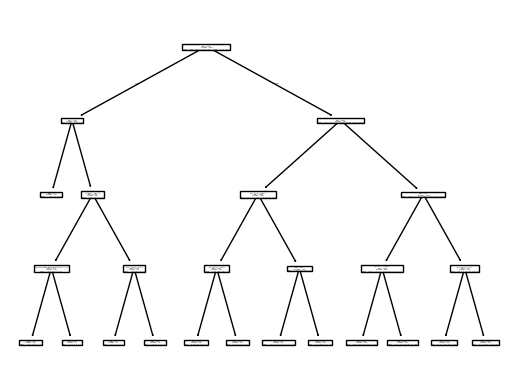

Unieke platforms in voorspellingen: {'PSP', 'PS2', 'PS', 'Wii', 'PS3', 'DS'}


In [79]:
dtree = DecisionTreeClassifier(max_depth = 4)
dtree = dtree.fit(X_train, y_train)
tree.plot_tree(dtree, feature_names = X.columns)
plt.show()


# Decision tree met extra parameters om overfitting en onbalans te voorkomen
# dtree = DecisionTreeClassifier(
#     max_depth=4,         
#     min_samples_leaf=1,    
#     class_weight='balanced', 
#     min_impurity_decrease=0
# )

# dtree.fit(X_train, y_train)

# plt.figure(figsize=(12, 8))
# plot_tree(
#     dtree,
#     feature_names=X.columns,  
#     class_names=dtree.classes_,  
#     filled=True,  
#     rounded=True
# )
# plt.show()

y_pred = dtree.predict(X_test)
print("Unieke platforms in voorspellingen:", set(y_pred))

In [80]:
predicted_df = pd.DataFrame(dtree.predict(X_test))
predicted_df = predicted_df.rename(columns = {0 : 'Predicted_Platform'})
model_results_frame = pd.concat([y_test.reset_index()['Platform'], predicted_df], axis = 1)
model_results_frame

,Platform,Predicted_Platform
0,DS,DS
1,PSP,DS
2,PSP,DS
3,PS2,PS2
4,Wii,DS
...,...,...
1567,DS,Wii
1568,X360,PS3
1569,PSP,PSP
1570,PS3,PS3


Unieke platformen in dataset:  ['DS' 'PSP' 'PS2' 'Wii' 'PS3' 'PS' 'X360']

Unieke platformen in voorspellingen:  ['DS' 'PS2' 'Wii' 'PSP' 'PS' 'PS3']


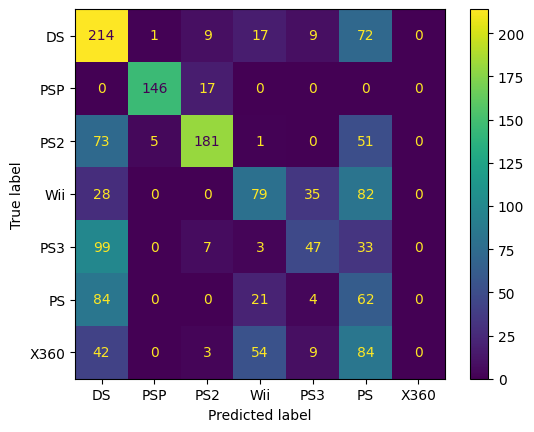

In [81]:
print("Unieke platformen in dataset: ", model_results_frame['Platform'].unique())
print()
print("Unieke platformen in voorspellingen: ", model_results_frame['Predicted_Platform'].unique())

confusion_matrix = metrics.confusion_matrix(model_results_frame['Platform'], model_results_frame['Predicted_Platform'])
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = model_results_frame['Platform'].unique())

cm_display.plot()
plt.show()

In [82]:
metrics.accuracy_score(model_results_frame['Platform'], model_results_frame['Predicted_Platform'])

0.4637404580152672

### Max_depth = 10


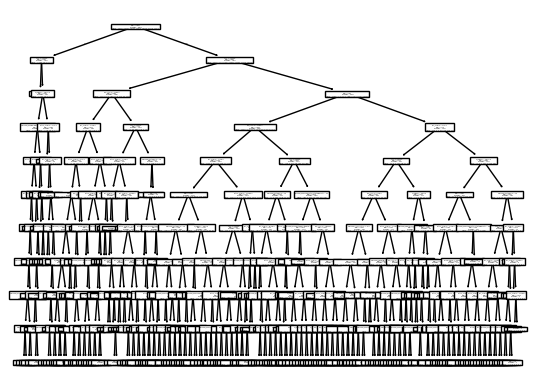

Unieke platforms in voorspellingen: {'PSP', 'PS2', 'PS', 'X360', 'PS3', 'Wii', 'DS'}


In [83]:
dtree = DecisionTreeClassifier(max_depth = 10)
dtree = dtree.fit(X_train, y_train)
tree.plot_tree(dtree, feature_names = X.columns)
plt.show()

# dtree = DecisionTreeClassifier(
#     max_depth=10,         
#     min_samples_leaf=1,    
#     class_weight='balanced', 
#     min_impurity_decrease=0
# )

# dtree.fit(X_train, y_train)

# plt.figure(figsize=(12, 8))
# plot_tree(
#     dtree,
#     feature_names=X.columns,  
#     class_names=dtree.classes_,  
#     filled=True,  
#     rounded=True
# )
# plt.show()

y_pred = dtree.predict(X_test)
print("Unieke platforms in voorspellingen:", set(y_pred))

In [84]:
predicted_df = pd.DataFrame(dtree.predict(X_test))
predicted_df = predicted_df.rename(columns = {0 : 'Predicted_Platform'})
model_results_frame = pd.concat([y_test.reset_index()['Platform'], predicted_df], axis = 1)
model_results_frame

,Platform,Predicted_Platform
0,DS,DS
1,PSP,DS
2,PSP,DS
3,PS2,PS2
4,Wii,DS
...,...,...
1567,DS,PS2
1568,X360,X360
1569,PSP,PS3
1570,PS3,PS3


Unieke platformen in dataset:  ['DS' 'PSP' 'PS2' 'Wii' 'PS3' 'PS' 'X360']

Unieke platformen in voorspellingen:  ['DS' 'PS2' 'PSP' 'Wii' 'PS3' 'PS' 'X360']


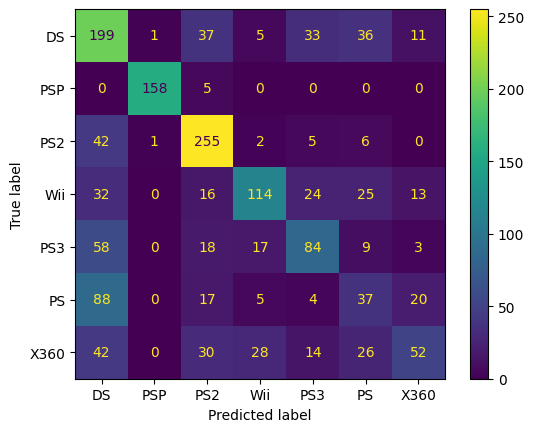

In [85]:
print("Unieke platformen in dataset: ", model_results_frame['Platform'].unique())
print()
print("Unieke platformen in voorspellingen: ", model_results_frame['Predicted_Platform'].unique())

confusion_matrix = metrics.confusion_matrix(model_results_frame['Platform'], model_results_frame['Predicted_Platform'])
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = model_results_frame['Platform'].unique())

cm_display.plot()
plt.show()

In [86]:
metrics.accuracy_score(model_results_frame['Platform'], model_results_frame['Predicted_Platform'])

0.571882951653944

### Geen Max_depth

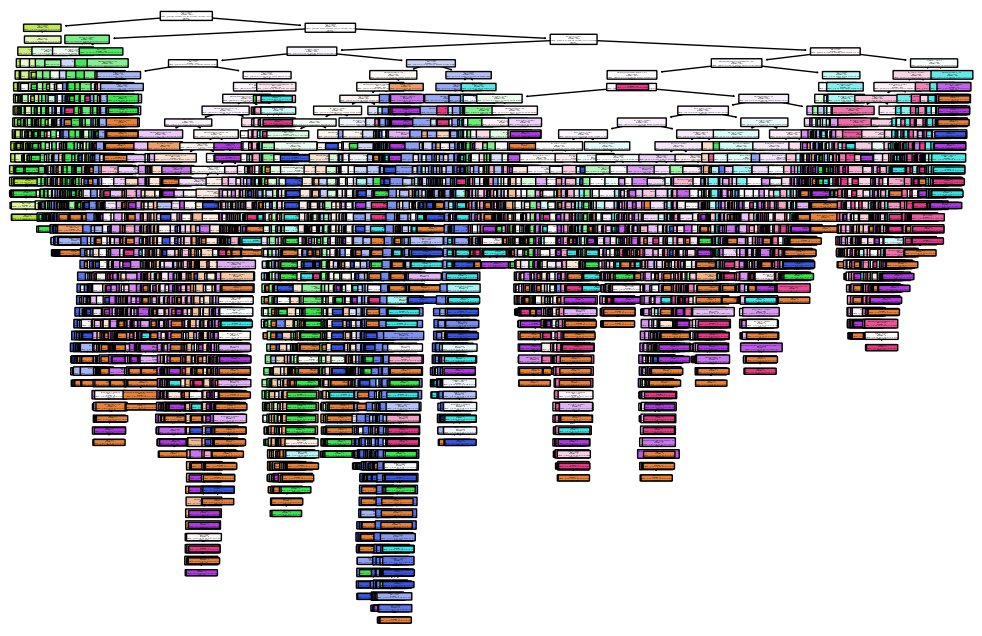

Unieke platforms in voorspellingen: {'PSP', 'PS2', 'X360', 'PS', 'PS3', 'Wii', 'DS'}


In [87]:
# dtree = DecisionTreeClassifier()
# dtree = dtree.fit(X_train, y_train)
# tree.plot_tree(dtree, feature_names = X.columns)
# plt.show()

dtree = DecisionTreeClassifier(
    max_depth=None,         
    min_samples_leaf=1,    
    class_weight='balanced', 
    min_impurity_decrease=0
)

dtree.fit(X_train, y_train)

plt.figure(figsize=(12, 8))
plot_tree(
    dtree,
    feature_names=X.columns,  
    class_names=dtree.classes_,  
    filled=True,  
    rounded=True
)
plt.show()

y_pred = dtree.predict(X_test)
print("Unieke platforms in voorspellingen:", set(y_pred))

## Evalueren

In [88]:
predicted_df = pd.DataFrame(dtree.predict(X_test))
predicted_df = predicted_df.rename(columns = {0 : 'Predicted_Platform'})
model_results_frame = pd.concat([y_test.reset_index()['Platform'], predicted_df], axis = 1)
model_results_frame

,Platform,Predicted_Platform
0,DS,PSP
1,PSP,PS3
2,PSP,DS
3,PS2,PS2
4,Wii,DS
...,...,...
1567,DS,X360
1568,X360,X360
1569,PSP,PS3
1570,PS3,PS3


Unieke platformen in dataset:  ['DS' 'PSP' 'PS2' 'Wii' 'PS3' 'PS' 'X360']

Unieke platformen in voorspellingen:  ['PSP' 'PS3' 'DS' 'PS2' 'X360' 'PS' 'Wii']


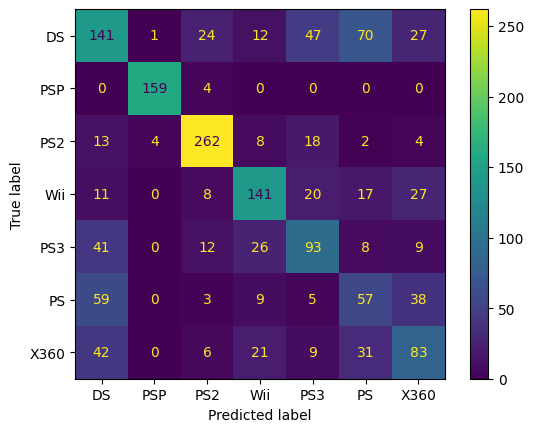

In [89]:
print("Unieke platformen in dataset: ", model_results_frame['Platform'].unique())
print()
print("Unieke platformen in voorspellingen: ", model_results_frame['Predicted_Platform'].unique())

confusion_matrix = metrics.confusion_matrix(model_results_frame['Platform'], model_results_frame['Predicted_Platform'])
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = model_results_frame['Platform'].unique())

cm_display.plot()
plt.show()

In [90]:
metrics.accuracy_score(model_results_frame['Platform'], model_results_frame['Predicted_Platform'])

0.5954198473282443